# BBBM Duration Sensitivity with Consistent Rate Refitting

## Motivation

The previous notebook (`bbbm_duration_sensitivity.ipynb`) swept Weibull scale while keeping
all other artifact rates fixed. This changed the BBBM-to-MCI transition rate without adjusting
other model parameters, potentially creating an inconsistent disease model.

## Approach

For each Weibull scale value, **re-run the DisMod consistent-rates fitting** from
`consistent_rates.py`. The MCMC fitting uses ODE consistency constraints that couple
the susceptible-to-BBBM transition rate (`h_S_to_BBBM`) to the BBBM-to-MCI rate
(`1 / BBBM_AVG_DURATION`), while fitting to the **same observed dementia prevalence and
incidence data** from the artifact. This automatically adjusts `h_S_to_BBBM` to compensate
for the different BBBM duration, keeping **total-population dementia prevalence** approximately
constant.

### Key distinction: total-population vs conditional prevalence

- **Total-population dementia prevalence** = `p_any * (1 - delta_BBBM - delta_MCI)`: the fraction of
  the entire population (including susceptible) with dementia. This is what GBD measures and
  what the MCMC constrains. **Held approximately constant by refitting.**
- **Conditional dementia prevalence** = `1 - delta_BBBM - delta_MCI`: the fraction of the *diseased*
  population (BBBM+MCI+Dementia) in the dementia state. Since the simulation models only the
  diseased population (no susceptible state), this is what appears as "dementia prevalence" in
  simulation output. **Varies structurally with BBBM duration** -- longer BBBM duration means
  a larger share of disease time is spent in BBBM, mechanically reducing the dementia fraction.

### Pipeline per scale value

1. Copy the base artifact to a temporary HDF file
2. Patch `BBBM_AVG_DURATION` in the fitting module
3. Re-run `generate_consistent_rates()` on the copy (MCMC fit, ~5 min)
4. Re-run `generate_consistent_susceptible_to_bbbm_transition_count()`
5. Re-run `generate_consistent_dementia_conditional_prevalence()`
6. Re-run `generate_consistent_csmr()`
7. Run ctrl + treat simulations using the re-fitted artifact
8. Compute metrics

In [1]:
import math
import os
import shutil
from contextlib import contextmanager

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from tqdm.auto import tqdm
from vivarium import InteractiveContext
from vivarium.framework.artifact import Artifact

from loguru import logger
logger.disable("vivarium")

import vivarium_csu_alzheimers.constants.data_values as dv_mod
import vivarium_csu_alzheimers.components.alzheimers as alz_mod
import vivarium_csu_alzheimers.data.consistent_rates as cr_mod
from vivarium_csu_alzheimers.data.consistent_rates import (
    generate_consistent_rates,
    generate_consistent_susceptible_to_bbbm_transition_count,
    generate_consistent_dementia_conditional_prevalence,
    generate_consistent_csmr,
)

# --- Constants ---
SPEC_PATH = '../src/vivarium_csu_alzheimers/model_specifications/model_spec.yaml'
BASE_ARTIFACT = '../united_states_of_america.hdf'
ARTIFACT_DIR = '../artifacts_sweep'  # directory for per-scale copies
POPULATION_SIZE = 10_000
STEP_SIZE_DAYS = 182
STEP_SIZE_YEARS = STEP_SIZE_DAYS / 365.25

DISEASE_COL = 'alzheimers_disease_and_other_dementias'
BBBM_STATE = 'alzheimers_blood_based_biomarker_state'
MCI_STATE = 'alzheimers_mild_cognitive_impairment_state'
DEMENTIA_STATE = 'alzheimers_disease_state'
TREATMENT_COL = 'treatment'
TARGET_YEAR = 2070

DW_MCI = 0.021
DW_DEMENTIA = 0.258

WEIBULL_SHAPE = 1.22
DEFAULT_SCALE = 6.76

/home/abie/miniforge3/envs/vivarium_csu_alzheimers_simulation/lib/python3.11/site-packages/vivarium_public_health/plugins/parser.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


In [2]:
# Fewer values than the full sweep — each requires MCMC fitting (~5 min) + 2 sim runs
SWEEP_VALUES = [3, 4, 5, 6, 6.76, 8, 9, 10, 12, 15, 18, 21, 25, 30]

print(f'Weibull shape (fixed): {WEIBULL_SHAPE}')
print(f'Default scale: {DEFAULT_SCALE}')
print()
print(f'{"Scale":>7s}  {"Mean duration (yr)":>18s}  {"h_BBBM_to_MCI":>14s}')
print('-' * 44)
for s in SWEEP_VALUES:
    dist = scipy.stats.weibull_min(WEIBULL_SHAPE, scale=s)
    marker = ' <-- default' if s == DEFAULT_SCALE else ''
    print(f'{s:>7.2f}  {dist.mean():>18.2f}  {1/dist.mean():>14.4f}{marker}')

Weibull shape (fixed): 1.22
Default scale: 6.76

  Scale  Mean duration (yr)   h_BBBM_to_MCI
--------------------------------------------
   3.00                2.81          0.3558
   4.00                3.75          0.2669
   5.00                4.68          0.2135
   6.00                5.62          0.1779
   6.76                6.33          0.1579 <-- default
   8.00                7.49          0.1334
   9.00                8.43          0.1186
  10.00                9.37          0.1068
  12.00               11.24          0.0890
  15.00               14.05          0.0712
  18.00               16.86          0.0593
  21.00               19.67          0.0508
  25.00               23.42          0.0427
  30.00               28.10          0.0356


In [3]:
@contextmanager
def patch_weibull_for_fitting(scale):
    """
    Patch BBBM_AVG_DURATION in all modules so that generate_consistent_rates
    uses the correct h_BBBM_to_MCI = 1 / BBBM_AVG_DURATION in its ODE.
    """
    new_dist = scipy.stats.weibull_min(WEIBULL_SHAPE, scale=scale)
    new_avg = new_dist.mean()

    saved = {
        'dv_scale': dv_mod.WEIBULL_SCALE,
        'dv_dist': dv_mod.BBBM_HAZARD_DIST,
        'dv_avg': dv_mod.BBBM_AVG_DURATION,
        'alz_dist': alz_mod.BBBM_HAZARD_DIST,
        'alz_avg': alz_mod.BBBM_AVG_DURATION,
        'cr_avg': cr_mod.BBBM_AVG_DURATION,
    }

    try:
        dv_mod.WEIBULL_SCALE = scale
        dv_mod.BBBM_HAZARD_DIST = new_dist
        dv_mod.BBBM_AVG_DURATION = new_avg
        alz_mod.BBBM_HAZARD_DIST = new_dist
        alz_mod.BBBM_AVG_DURATION = new_avg
        cr_mod.BBBM_AVG_DURATION = new_avg
        yield
    finally:
        dv_mod.WEIBULL_SCALE = saved['dv_scale']
        dv_mod.BBBM_HAZARD_DIST = saved['dv_dist']
        dv_mod.BBBM_AVG_DURATION = saved['dv_avg']
        alz_mod.BBBM_HAZARD_DIST = saved['alz_dist']
        alz_mod.BBBM_AVG_DURATION = saved['alz_avg']
        cr_mod.BBBM_AVG_DURATION = saved['cr_avg']


def build_refitted_artifact(scale):
    """
    Copy the base artifact and re-run consistent-rates fitting for a given
    Weibull scale. Returns the path to the refitted artifact.
    """
    os.makedirs(ARTIFACT_DIR, exist_ok=True)
    art_path = os.path.join(ARTIFACT_DIR, f'artifact_scale_{scale}.hdf')

    # If already built, skip
    if os.path.exists(art_path):
        print(f'  Reusing existing artifact for scale={scale}')
        return os.path.abspath(art_path)

    print(f'  Copying base artifact...')
    shutil.copy2(BASE_ARTIFACT, art_path)

    print(f'  Refitting consistent rates (MCMC) for scale={scale}...')
    with patch_weibull_for_fitting(scale):
        art = Artifact(art_path)
        generate_consistent_rates(art)
        generate_consistent_susceptible_to_bbbm_transition_count(art)
        generate_consistent_dementia_conditional_prevalence(art)
        generate_consistent_csmr(art)

    print(f'  Done: {art_path}')
    return os.path.abspath(art_path)

In [4]:
def run_scenario(scenario, artifact_path, scale, target_year=TARGET_YEAR, pbar_position=None):
    """
    Run a scenario using a specific artifact (possibly refitted).
    Weibull scale/dist must be patched in the calling context.
    """
    sim = InteractiveContext(
        SPEC_PATH,
        configuration={
            'population': {'population_size': POPULATION_SIZE},
            'intervention': {'scenario': scenario},
            'input_data': {'artifact_path': artifact_path},
        }
    )

    target = pd.Timestamp(f'{target_year}-01-01')
    est_steps = max(1, math.ceil((target - sim.current_time).days / STEP_SIZE_DAYS))

    person_steps_bbbm = 0
    person_steps_mci = 0
    person_steps_dementia = 0
    total_alive_steps = 0
    yll = 0.0
    pipeline_entrants = set()
    alive_set = set()

    is_treatment = (scenario == 'bbbm_testing_and_treatment')
    PIPELINE_STATES = {
        'waiting_for_treatment', 'treatment_effect', 'waning_effect',
        'no_effect_after_treatment', 'no_effect_never_treated',
        'positive_test',
    }

    tqdm_kwargs = dict(total=est_steps, desc=scenario.replace('bbbm_', ''), unit='step')
    if pbar_position is not None:
        tqdm_kwargs['position'] = pbar_position
        tqdm_kwargs['leave'] = False

    with tqdm(**tqdm_kwargs) as pbar:
        while sim.current_time < target:
            sim.step()
            pop = sim.get_population()
            alive = pop[pop['alive'] == 'alive']
            current_alive = set(alive.index)

            newly_dead = alive_set - current_alive
            for sid in newly_dead:
                if sid in pop.index:
                    yll += pop.loc[sid, 'years_of_life_lost']
            alive_set = current_alive

            disease_states = alive[DISEASE_COL]
            person_steps_bbbm += (disease_states == BBBM_STATE).sum()
            person_steps_mci += (disease_states == MCI_STATE).sum()
            person_steps_dementia += (disease_states == DEMENTIA_STATE).sum()
            total_alive_steps += len(alive)

            if is_treatment and TREATMENT_COL in alive.columns:
                in_pipeline = set(alive.index[alive[TREATMENT_COL].isin(PIPELINE_STATES)])
                pipeline_entrants |= in_pipeline

            pbar.update(1)

    return {
        'person_steps_bbbm': person_steps_bbbm,
        'person_steps_mci': person_steps_mci,
        'person_steps_dementia': person_steps_dementia,
        'total_alive_steps': total_alive_steps,
        'yll': yll,
        'n_pipeline_entrants': len(pipeline_entrants),
    }

In [5]:
def compute_metrics(ctrl_data, treat_data, scale):
    mean_duration = scipy.stats.weibull_min(WEIBULL_SHAPE, scale=scale).mean()

    bbbm_prevalence = ctrl_data['person_steps_bbbm'] / ctrl_data['total_alive_steps']
    mci_prevalence_ctrl = ctrl_data['person_steps_mci'] / ctrl_data['total_alive_steps']
    dementia_prevalence_ctrl = ctrl_data['person_steps_dementia'] / ctrl_data['total_alive_steps']
    mci_prevalence_treat = treat_data['person_steps_mci'] / treat_data['total_alive_steps']
    dementia_prevalence_treat = treat_data['person_steps_dementia'] / treat_data['total_alive_steps']

    yld_ctrl = (ctrl_data['person_steps_mci'] * DW_MCI +
                ctrl_data['person_steps_dementia'] * DW_DEMENTIA) * STEP_SIZE_YEARS
    yld_treat = (treat_data['person_steps_mci'] * DW_MCI +
                 treat_data['person_steps_dementia'] * DW_DEMENTIA) * STEP_SIZE_YEARS
    yld_averted = yld_ctrl - yld_treat
    yll_averted = ctrl_data['yll'] - treat_data['yll']
    dalys_averted = yld_averted + yll_averted

    n_entrants = treat_data['n_pipeline_entrants']
    dalys_per_entrant = dalys_averted / n_entrants if n_entrants > 0 else 0.0

    return {
        'scale': scale,
        'mean_duration': mean_duration,
        'bbbm_prevalence': bbbm_prevalence,
        'mci_prevalence_ctrl': mci_prevalence_ctrl,
        'dementia_prevalence_ctrl': dementia_prevalence_ctrl,
        'mci_prevalence_treat': mci_prevalence_treat,
        'dementia_prevalence_treat': dementia_prevalence_treat,
        'yld_averted': yld_averted,
        'yll_averted': yll_averted,
        'dalys_averted': dalys_averted,
        'n_pipeline_entrants': n_entrants,
        'dalys_per_entrant': dalys_per_entrant,
    }

In [6]:
# --- Step 1: Build refitted artifacts for each scale value ---
# This is the slow step (~5 min MCMC per scale, run once and cached).
artifact_paths = {}

for scale in tqdm(SWEEP_VALUES, desc='Building artifacts', unit='scale'):
    if scale == DEFAULT_SCALE:
        # Use the original artifact for the default scale
        artifact_paths[scale] = os.path.abspath(BASE_ARTIFACT)
        print(f'  scale={scale}: using base artifact (no refit needed)')
    else:
        artifact_paths[scale] = build_refitted_artifact(scale)

print('\nAll artifacts ready.')

Building artifacts:   0%|          | 0/14 [00:00<?, ?scale/s]

  Reusing existing artifact for scale=3
  Copying base artifact...
  Refitting consistent rates (MCMC) for scale=4...


sample: 100%|██████████| 1000/1000 [05:20<00:00,  3.12it/s, 1023 steps of size 8.23e-04. acc. prob=0.90]


  Done: ../artifacts_sweep/artifact_scale_4.hdf
  Reusing existing artifact for scale=5
  Copying base artifact...
  Refitting consistent rates (MCMC) for scale=6...


sample: 100%|██████████| 1000/1000 [05:23<00:00,  3.09it/s, 1023 steps of size 1.91e-03. acc. prob=0.92]


...

  Done: ../artifacts_sweep/artifact_scale_21.hdf
  Copying base artifact...
  Refitting consistent rates (MCMC) for scale=25...


sample: 100%|██████████| 1000/1000 [05:23<00:00,  3.09it/s, 1023 steps of size 2.31e-03. acc. prob=0.96]


  Done: ../artifacts_sweep/artifact_scale_25.hdf
  Copying base artifact...
  Refitting consistent rates (MCMC) for scale=30...


sample: 100%|██████████| 1000/1000 [06:28<00:00,  2.57it/s, 1023 steps of size 3.42e-03. acc. prob=0.92]


  Done: ../artifacts_sweep/artifact_scale_30.hdf

All artifacts ready.


In [7]:
# --- Verify artifact consistency ---
# The MCMC constrains p_dementia = p_any * (1 - delta_BBBM - delta_MCI) to match GBD data.
# Total-pop dementia prevalence should be approximately constant across scale values,
# while conditional prevalence (Dem|D) varies structurally.

artifact_metrics = {}

print("Artifact-level rates and prevalences (draw_0, mean across ages, Female):\n")
print(f"{'Scale':>7s}  {'h_S->BBBM':>10s}  {'p(any)':>8s}  "
      f"{'BBBM|D':>8s}  {'MCI|D':>8s}  {'Dem|D':>8s}  {'p*Dem|D':>10s}")
print('-' * 75)

for scale in SWEEP_VALUES:
    art = Artifact(artifact_paths[scale])
    p_any = art.load("cause.alzheimers_consistent.prevalence_any")
    bbbm_c = art.load("cause.alzheimers_consistent.bbbm_conditional_prevalence")
    mci_c = art.load("cause.alzheimers_consistent.mci_conditional_prevalence")
    dem_c = art.load("cause.alzheimers_consistent.dementia_conditional_prevalence")
    h_s2b = art.load("cause.alzheimers_consistent.population_incidence_any")

    p_f = p_any.loc['Female']['draw_0'].mean()
    b_f = bbbm_c.loc['Female']['draw_0'].mean()
    m_f = mci_c.loc['Female']['draw_0'].mean()
    d_f = dem_c.loc['Female']['draw_0'].mean()
    h_f = h_s2b.loc['Female']['draw_0'].mean()

    artifact_metrics[scale] = {
        'p_any': p_f, 'bbbm_cond': b_f, 'mci_cond': m_f,
        'dem_cond': d_f, 'h_s2b': h_f, 'total_pop_dem': p_f * d_f,
    }

    marker = ' *' if scale == DEFAULT_SCALE else ''
    print(f"{scale:>7.2f}  {h_f:>10.5f}  {p_f:>8.4f}  "
          f"{b_f:>8.4f}  {m_f:>8.4f}  {d_f:>8.4f}  "
          f"{p_f * d_f:>10.6f}{marker}")

default_tp = artifact_metrics[DEFAULT_SCALE]['total_pop_dem']
default_dc = artifact_metrics[DEFAULT_SCALE]['dem_cond']

print(f"\nTotal-pop dementia prevalence (p*Dem|D) relative to default ({default_tp:.6f}):")
for scale in SWEEP_VALUES:
    tp = artifact_metrics[scale]['total_pop_dem']
    ratio = tp / default_tp
    print(f"  scale={scale:>5.2f}:  {tp:.6f}  ({ratio:.2f}x)")

print(f"\nConditional dementia prevalence (Dem|D) relative to default ({default_dc:.4f}):")
for scale in SWEEP_VALUES:
    dc = artifact_metrics[scale]['dem_cond']
    ratio = dc / default_dc
    print(f"  scale={scale:>5.2f}:  {dc:.4f}  ({ratio:.2f}x)")

print("\n--> Total-pop dementia prevalence is approximately constant (MCMC working correctly)")
print("    Conditional dementia prevalence varies -- structural consequence of disease model")
print("    h_S->BBBM adjusts to compensate for different BBBM duration")

Artifact-level rates and prevalences (draw_0, mean across ages, Female):

  Scale   h_S->BBBM    p(any)    BBBM|D     MCI|D     Dem|D     p*Dem|D
---------------------------------------------------------------------------


   3.00     0.01134    0.1131    0.2678    0.2709    0.4613    0.052174
   4.00     0.01256    0.1247    0.3297    0.2462    0.4240    0.052898
   5.00     0.01665    0.1498    0.4127    0.2798    0.3227    0.048330
   6.00     0.01670    0.1554    0.4373    0.2303    0.3324    0.051662
   6.76     0.01424    0.1402    0.4551    0.2014    0.3435    0.048164 *
   8.00     0.01687    0.1707    0.5048    0.2307    0.2645    0.045139
   9.00     0.01737    0.1751    0.5571    0.2351    0.2475    0.043349
  10.00     0.01815    0.1898    0.5348    0.2196    0.2464    0.046757
  12.00     0.01887    0.2028    0.5786    0.2078    0.2292    0.046482
  15.00     0.02193    0.2323    0.6287    0.1874    0.1986    0.046135
  18.00     0.02601    0.2583    0.6659    0.1664    0.1678    0.043332
  21.00     0.03169    0.2948    0.6971    0.1547    0.1514    0.044630
  25.00     0.19886    0.3597    0.7271    0.1480    0.1363    0.049031
  30.00     0.23944    0.3763    0.7539    0.1348    0.1208   

In [8]:
# --- Step 2: Run simulations using refitted artifacts ---
# Results are checkpointed after each scale value to protect against crashes.
import pickle

RESULTS_CACHE = os.path.join(ARTIFACT_DIR, 'sweep_results_cache.pkl')

# Load any previously completed results
cached = {}
if os.path.exists(RESULTS_CACHE):
    with open(RESULTS_CACHE, 'rb') as f:
        cached = pickle.load(f)
    print(f'Loaded {len(cached)} cached scale results: {sorted(cached.keys())}')

results = []

with tqdm(total=len(SWEEP_VALUES), desc='Simulation sweep', unit='val', position=0) as outer:
    for scale in SWEEP_VALUES:
        outer.set_postfix_str(f'scale={scale}')

        if scale in cached:
            results.append(cached[scale])
            outer.update(1)
            continue

        art_path = artifact_paths[scale]

        with patch_weibull_for_fitting(scale):
            ctrl = run_scenario('bbbm_testing', art_path, scale, pbar_position=1)
            treat = run_scenario('bbbm_testing_and_treatment', art_path, scale, pbar_position=2)

        metrics = compute_metrics(ctrl, treat, scale)
        results.append(metrics)
        cached[scale] = metrics

        # Checkpoint after each scale
        with open(RESULTS_CACHE, 'wb') as f:
            pickle.dump(cached, f)

        outer.update(1)

df = pd.DataFrame(results)
print(f'\nSweep complete: {len(df)} scale values evaluated.')

Simulation sweep:   0%|          | 0/14 [00:00<?, ?val/s]

testing:   0%|          | 0/97 [00:00<?, ?step/s]

testing_and_treatment:   0%|          | 0/97 [00:00<?, ?step/s]

testing:   0%|          | 0/97 [00:00<?, ?step/s]

testing_and_treatment:   0%|          | 0/97 [00:00<?, ?step/s]

...

testing:   0%|          | 0/97 [00:00<?, ?step/s]

testing_and_treatment:   0%|          | 0/97 [00:00<?, ?step/s]

testing:   0%|          | 0/97 [00:00<?, ?step/s]

testing_and_treatment:   0%|          | 0/97 [00:00<?, ?step/s]


Sweep complete: 14 scale values evaluated.


In [9]:
# --- Summary table ---
print(f'Population = {POPULATION_SIZE:,}, simulation to {TARGET_YEAR}')
print('Artifacts refitted with consistent rates for each scale value.')
print()
print('Dem(sim)  = conditional prevalence among diseased population (from simulation)')
print('Dem(pop)  = estimated total-population prevalence = Dem(sim) x p(any)')
print()

hdr = (f'{"Scale":>7s}  {"Mean dur":>8s}  {"BBBM prev":>9s}  '
       f'{"Dem(sim)":>8s}  {"Dem(pop)":>9s}  '
       f'{"DALYs":>8s}  {"Pipeline":>8s}  {"DA/ent":>7s}')
print(hdr)
print('-' * len(hdr))

for _, row in df.iterrows():
    scale = row['scale']
    marker = ' *' if scale == DEFAULT_SCALE else ''
    p_any = artifact_metrics[scale]['p_any']
    dem_pop = row['dementia_prevalence_ctrl'] * p_any
    print(f'{scale:>7.2f}  {row["mean_duration"]:>8.2f}  '
          f'{row["bbbm_prevalence"]:>9.4f}  '
          f'{row["dementia_prevalence_ctrl"]:>8.4f}  '
          f'{dem_pop:>9.5f}  '
          f'{row["dalys_averted"]:>8.1f}  '
          f'{row["n_pipeline_entrants"]:>8.0f}  '
          f'{row["dalys_per_entrant"]:>7.3f}{marker}')

# Show comparison
default_sim = df.loc[df['scale'] == DEFAULT_SCALE, 'dementia_prevalence_ctrl'].values[0]
default_p_any = artifact_metrics[DEFAULT_SCALE]['p_any']
default_pop = default_sim * default_p_any

print(f'\nDementia prevalence relative to default:')
print(f'  {"Scale":>7s}  {"Dem(sim)":>10s} {"ratio":>6s}   {"Dem(pop)":>10s} {"ratio":>6s}')
for _, row in df.iterrows():
    scale = row['scale']
    sim_val = row['dementia_prevalence_ctrl']
    sim_ratio = sim_val / default_sim
    p_any = artifact_metrics[scale]['p_any']
    pop_val = sim_val * p_any
    pop_ratio = pop_val / default_pop
    print(f'  {scale:>7.2f}  {sim_val:>10.4f} {sim_ratio:>5.2f}x   '
          f'{pop_val:>10.5f} {pop_ratio:>5.2f}x')

sim_min = df['dementia_prevalence_ctrl'].min() / default_sim
sim_max = df['dementia_prevalence_ctrl'].max() / default_sim
pop_ratios = [row['dementia_prevalence_ctrl'] * artifact_metrics[row['scale']]['p_any'] / default_pop
              for _, row in df.iterrows()]
pop_min, pop_max = min(pop_ratios), max(pop_ratios)
print(f'\n  Dem(sim) = conditional prevalence -- varies {sim_min:.2f}x-{sim_max:.2f}x (structural)')
print(f'  Dem(pop) = total-population prevalence -- varies {pop_min:.2f}x-{pop_max:.2f}x (MCMC-constrained)')

Population = 10,000, simulation to 2070
Artifacts refitted with consistent rates for each scale value.

Dem(sim)  = conditional prevalence among diseased population (from simulation)
Dem(pop)  = estimated total-population prevalence = Dem(sim) x p(any)

  Scale  Mean dur  BBBM prev  Dem(sim)   Dem(pop)     DALYs  Pipeline   DA/ent
------------------------------------------------------------------------------
   3.00      2.81     0.2666    0.4485    0.05073     886.4      6052    0.146
   4.00      3.75     0.3307    0.4106    0.05122    1314.1      7499    0.175
   5.00      4.68     0.4056    0.3456    0.05177    1797.2      8477    0.212
   6.00      5.62     0.4548    0.3155    0.04904    2017.0      9401    0.215
   6.76      6.33     0.4771    0.3111    0.04361    2028.2      9456    0.214 *
   8.00      7.49     0.5292    0.2748    0.04690    2022.8     10054    0.201
   9.00      8.43     0.5676    0.2484    0.04351    1880.4     10635    0.177
  10.00      9.37     0.5993    0

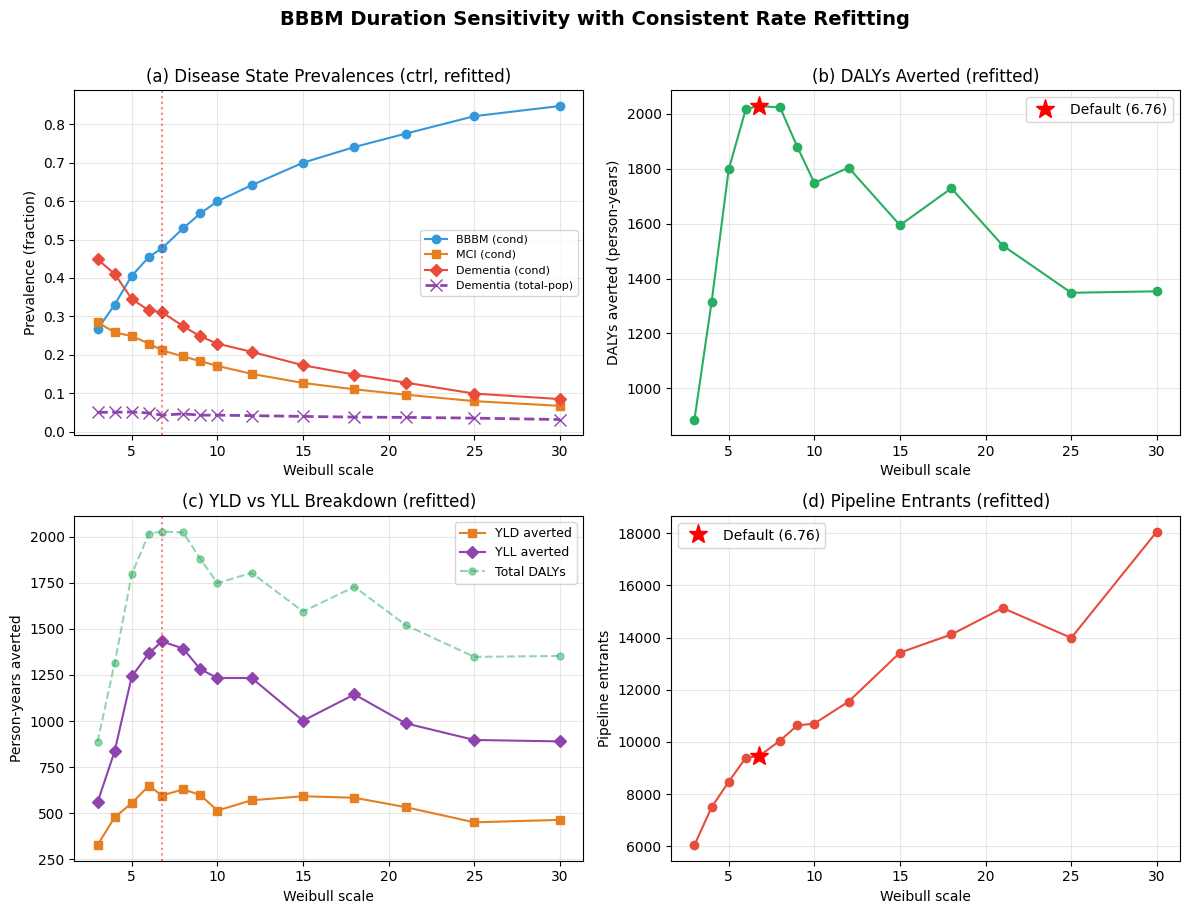

In [10]:
# --- 4-panel figure ---
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
default_mask = df['scale'] == DEFAULT_SCALE

# (a) Disease state prevalences — conditional (sim) + total-pop dementia
ax = axes[0, 0]
ax.plot(df['scale'], df['bbbm_prevalence'], 'o-', color='#3498db', markersize=6, label='BBBM (cond)')
ax.plot(df['scale'], df['mci_prevalence_ctrl'], 's-', color='#e67e22', markersize=6, label='MCI (cond)')
ax.plot(df['scale'], df['dementia_prevalence_ctrl'], 'D-', color='#e74c3c', markersize=6, label='Dementia (cond)')
# Total-pop dementia prevalence (sim-derived)
dem_pop = [row['dementia_prevalence_ctrl'] * artifact_metrics[row['scale']]['p_any']
           for _, row in df.iterrows()]
ax.plot(df['scale'], dem_pop, 'x--', color='#8e44ad', markersize=8, linewidth=2, label='Dementia (total-pop)')
ax.axvline(x=DEFAULT_SCALE, color='red', linestyle=':', alpha=0.5)
ax.set_xlabel('Weibull scale')
ax.set_ylabel('Prevalence (fraction)')
ax.set_title('(a) Disease State Prevalences (ctrl, refitted)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# (b) DALYs averted
ax = axes[0, 1]
ax.plot(df['scale'], df['dalys_averted'], 'o-', color='#27ae60', markersize=6)
ax.plot(df.loc[default_mask, 'scale'], df.loc[default_mask, 'dalys_averted'],
        '*', color='red', markersize=14, zorder=5, label=f'Default ({DEFAULT_SCALE})')
ax.set_xlabel('Weibull scale')
ax.set_ylabel('DALYs averted (person-years)')
ax.set_title('(b) DALYs Averted (refitted)')
ax.legend()
ax.grid(True, alpha=0.3)

# (c) YLD vs YLL breakdown
ax = axes[1, 0]
ax.plot(df['scale'], df['yld_averted'], 's-', color='#e67e22', markersize=6, label='YLD averted')
ax.plot(df['scale'], df['yll_averted'], 'D-', color='#8e44ad', markersize=6, label='YLL averted')
ax.plot(df['scale'], df['dalys_averted'], 'o--', color='#27ae60', markersize=5, alpha=0.5, label='Total DALYs')
ax.axvline(x=DEFAULT_SCALE, color='red', linestyle=':', alpha=0.5)
ax.set_xlabel('Weibull scale')
ax.set_ylabel('Person-years averted')
ax.set_title('(c) YLD vs YLL Breakdown (refitted)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# (d) Pipeline entrants
ax = axes[1, 1]
ax.plot(df['scale'], df['n_pipeline_entrants'], 'o-', color='#e74c3c', markersize=6)
ax.plot(df.loc[default_mask, 'scale'], df.loc[default_mask, 'n_pipeline_entrants'],
        '*', color='red', markersize=14, zorder=5, label=f'Default ({DEFAULT_SCALE})')
ax.set_xlabel('Weibull scale')
ax.set_ylabel('Pipeline entrants')
ax.set_title('(d) Pipeline Entrants (refitted)')
ax.legend()
ax.grid(True, alpha=0.3)

fig.suptitle('BBBM Duration Sensitivity with Consistent Rate Refitting',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

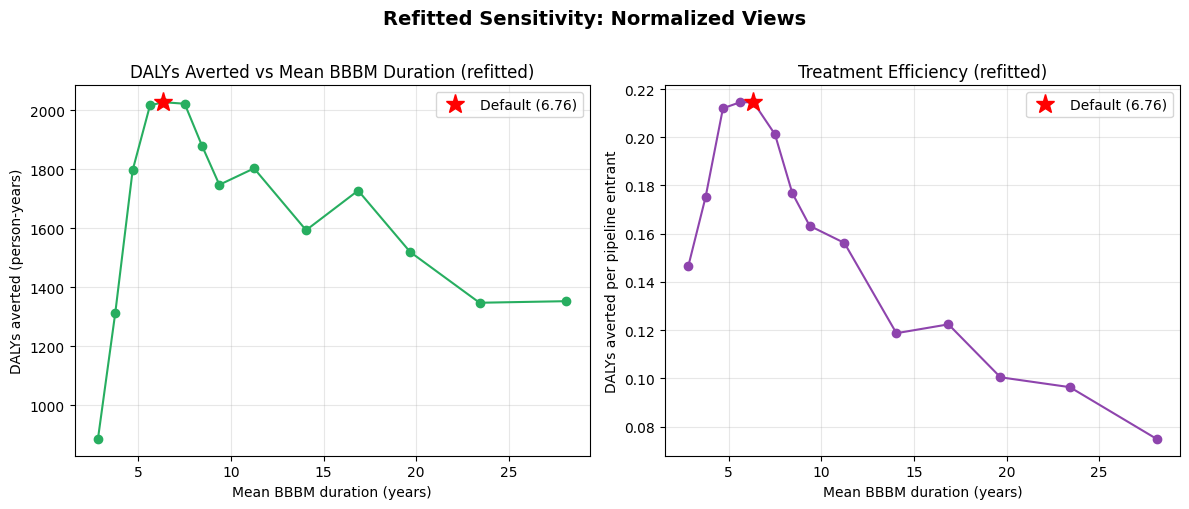

In [11]:
# --- 2-panel: DALYs vs mean duration, treatment efficiency ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot(df['mean_duration'], df['dalys_averted'], 'o-', color='#27ae60', markersize=6)
ax.plot(df.loc[default_mask, 'mean_duration'], df.loc[default_mask, 'dalys_averted'],
        '*', color='red', markersize=14, zorder=5, label=f'Default ({DEFAULT_SCALE})')
ax.set_xlabel('Mean BBBM duration (years)')
ax.set_ylabel('DALYs averted (person-years)')
ax.set_title('DALYs Averted vs Mean BBBM Duration (refitted)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(df['mean_duration'], df['dalys_per_entrant'], 'o-', color='#8e44ad', markersize=6)
ax.plot(df.loc[default_mask, 'mean_duration'], df.loc[default_mask, 'dalys_per_entrant'],
        '*', color='red', markersize=14, zorder=5, label=f'Default ({DEFAULT_SCALE})')
ax.set_xlabel('Mean BBBM duration (years)')
ax.set_ylabel('DALYs averted per pipeline entrant')
ax.set_title('Treatment Efficiency (refitted)')
ax.legend()
ax.grid(True, alpha=0.3)

fig.suptitle('Refitted Sensitivity: Normalized Views', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Interpretation

### What refitting achieves

By re-running the DisMod MCMC fitting for each Weibull scale, the model adjusts the
susceptible-to-BBBM transition rate (`h_S_to_BBBM`) to maintain ODE consistency with
the **same observed dementia prevalence and incidence** from the GBD data. This keeps
**total-population dementia prevalence** (`p_any * dem_cond`) approximately constant
across scale values.

### Why conditional prevalence still varies

The simulation models only the diseased population (BBBM + MCI + Dementia) with no
susceptible state. The fraction of this diseased population in dementia -- the
**conditional** prevalence -- is structurally determined by the ratio of disease state
durations. Longer BBBM duration mechanically increases the BBBM share and decreases
the dementia share. This is a mathematical identity of the disease model, not a
failure of the MCMC fitting.

The MCMC compensates by increasing `p_any` (overall disease prevalence) when BBBM
duration is longer, so that `p_any * dem_cond` stays constant. This means more people
enter the disease pool, but each spends a smaller fraction of their disease time in
dementia.

### Implications for DALYs averted

With refitted artifacts, the DALYs averted sensitivity to BBBM duration reflects the
combined effect of:

1. **BBBM pool size** (larger pool when duration is longer -- more testable people)
2. **Pipeline entrants** (monotonically increase with BBBM duration)
3. **Treatment efficiency** (DALYs averted per pipeline entrant -- depends on how much
   downstream disease burden each treated person avoids)
4. **Consistent epidemiology** (total-population disease burden is held constant by MCMC)

### Caveats

- MCMC fitting is stochastic -- slightly different rates across runs
- The ODE consistency constraints use a soft penalty (sigma=0.005), so approximate
  consistency rather than exact
- Each artifact is fitted independently; cross-scale comparison inherits MCMC noise
- Total-pop prevalence stability is within ~10%, not exact